# Keras Trasfer Learning with Optimization (Recalibration of weights)

In [1]:
import os

import numpy as np
import pandas as pd
for root, directory, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        print(os.path.join(root,f))
    
#check keras backend:
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.environ['POLARS_MAX_THREADS'] = '1'
os.environ['PYTHONHASHSEED'] = str(42)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import keras.config
keras.config.disable_traceback_filtering()

# Disable TensorFlow logging at the Python level
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)


import tensorflow as tf
import keras
from keras import backend as K
print(K.backend())

import polars as pl
from sklearn.preprocessing import *
from sklearn.pipeline import *
from sklearn.compose import *
from IPython.display import FileLink
import gc
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
base_link = "/kaggle/input/playground-series-s5e5/"
import sklearn
print(tf.__version__)
print(sklearn.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
pl.set_random_seed(11)
from tqdm.notebook import tqdm
from tqdm.keras import TqdmCallback
from sklearn.model_selection import *
from sklearn.metrics import *
import itertools


/kaggle/input/playground-series-s5e5/sample_submission.csv
/kaggle/input/playground-series-s5e5/train.csv
/kaggle/input/playground-series-s5e5/test.csv
/kaggle/input/calories-burnt-prediction/calories.csv


E0000 00:00:1747234783.921892      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747234784.033834      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tensorflow
2.18.0
1.2.2


In [2]:
original = pl.read_csv('/kaggle/input/calories-burnt-prediction/calories.csv')
original = original.with_columns(
    Sex = pl.col('Gender'),
    id = pl.lit(-1).cast(pl.Int64)
).select(pl.exclude('Gender', 'User_ID'))
original = original.select(['id','Sex','Age','Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories'])
original.head()

id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
i64,str,i64,f64,f64,f64,f64,f64,f64
-1,"""male""",68,190.0,94.0,29.0,105.0,40.8,231.0
-1,"""female""",20,166.0,60.0,14.0,94.0,40.3,66.0
-1,"""male""",69,179.0,79.0,5.0,88.0,38.7,26.0
-1,"""female""",34,179.0,71.0,13.0,100.0,40.5,71.0
-1,"""female""",27,154.0,58.0,10.0,81.0,39.8,35.0


In [3]:
train = pl.read_csv(os.path.join(base_link, 'train.csv'))
train.head()

id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
i64,str,i64,f64,f64,f64,f64,f64,f64
0,"""male""",36,189.0,82.0,26.0,101.0,41.0,150.0
1,"""female""",64,163.0,60.0,8.0,85.0,39.7,34.0
2,"""female""",51,161.0,64.0,7.0,84.0,39.8,29.0
3,"""male""",20,192.0,90.0,25.0,105.0,40.7,140.0
4,"""female""",38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
trx = train.clone()
FT = make_pipeline(PowerTransformer(method = 'box-cox'))
FT2 = PowerTransformer(method = 'box-cox')
z = FT.fit_transform(trx['Calories'].to_numpy().reshape(-1,1))
z2 = FT.fit_transform(trx['Body_Temp'].to_numpy().reshape(-1,1))
trx = trx.with_columns(
    CaloriesBoxCox = z.ravel(),
    #Body_Temp = z2.ravel()
)
trx.describe()

statistic,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,CaloriesBoxCox
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",750000.0,"""750000""",750000.0,750000.0,750000.0,750000.0,750000.0,750000.0,750000.0,750000.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",374999.5,null,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781,3.0644e-16
"""std""",216506.495284,null,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349,1.000001
"""min""",0.0,"""female""",20.0,126.0,36.0,1.0,67.0,37.1,1.0,-2.313627
"""25%""",187500.0,null,28.0,164.0,63.0,8.0,88.0,39.6,34.0,-0.787613
"""50%""",375000.0,null,40.0,174.0,74.0,15.0,95.0,40.3,77.0,0.048942
"""75%""",562499.0,null,52.0,185.0,87.0,23.0,103.0,40.7,136.0,0.835908
"""max""",749999.0,"""male""",79.0,222.0,132.0,30.0,128.0,41.5,314.0,2.416498


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


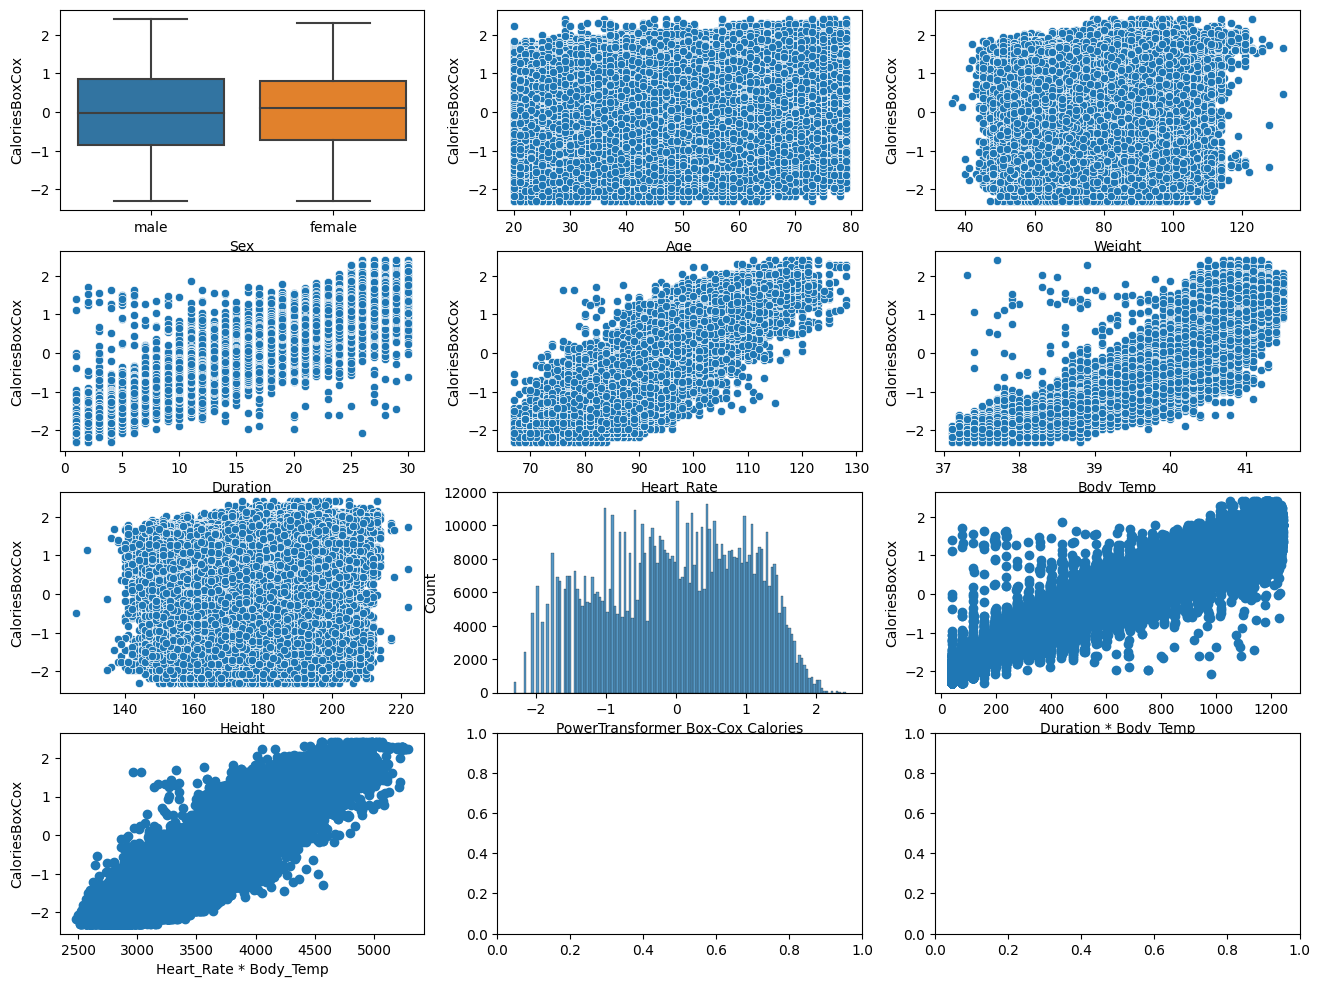

In [5]:
fig, ax = plt.subplots(figsize = (16,12), ncols = 3, nrows = 4)
df = trx.to_pandas()
sns.boxplot(data = df, x = 'Sex', y = 'CaloriesBoxCox', ax = ax[0,0])

sns.scatterplot(data = df, x = 'Age', y = 'CaloriesBoxCox', ax = ax[0,1])
sns.scatterplot(data = df, x = 'Weight', y = 'CaloriesBoxCox',ax = ax[0,2])
sns.scatterplot(data = df, x = 'Duration', y = 'CaloriesBoxCox', ax = ax[1,0])
sns.scatterplot(data = df, x = 'Heart_Rate', y = 'CaloriesBoxCox', ax = ax[1,1])
sns.scatterplot(data = df, x = 'Body_Temp', y = 'CaloriesBoxCox',ax =ax[1,2])
sns.scatterplot(data = df, x = 'Height', y = 'CaloriesBoxCox', ax = ax[2,0])
#feature:
sns.histplot(x = trx['CaloriesBoxCox'], ax = ax[2,1])
ax[2,1].set_xlabel('PowerTransformer Box-Cox Calories')
ax[2,2].scatter(trx['Duration'] * trx['Body_Temp'], trx['CaloriesBoxCox'])
ax[2,2].set_xlabel('Duration * Body_Temp')
ax[2,2].set_ylabel('CaloriesBoxCox')

ax[3,0].scatter(trx['Heart_Rate'] * trx['Body_Temp'], trx['CaloriesBoxCox'])
ax[3,0].set_xlabel('Heart_Rate * Body_Temp')
ax[3,0].set_ylabel('CaloriesBoxCox')

plt.show()
plt.close()

In [6]:
train.describe()

statistic,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
str,f64,str,f64,f64,f64,f64,f64,f64,f64
"""count""",750000.0,"""750000""",750000.0,750000.0,750000.0,750000.0,750000.0,750000.0,750000.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",374999.5,null,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
"""std""",216506.495284,null,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
"""min""",0.0,"""female""",20.0,126.0,36.0,1.0,67.0,37.1,1.0
"""25%""",187500.0,null,28.0,164.0,63.0,8.0,88.0,39.6,34.0
"""50%""",375000.0,null,40.0,174.0,74.0,15.0,95.0,40.3,77.0
"""75%""",562499.0,null,52.0,185.0,87.0,23.0,103.0,40.7,136.0
"""max""",749999.0,"""male""",79.0,222.0,132.0,30.0,128.0,41.5,314.0


In [7]:
test = pl.read_csv(os.path.join(base_link, 'test.csv'))
test.head()

id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
i64,str,i64,f64,f64,f64,f64,f64
750000,"""male""",45,177.0,81.0,7.0,87.0,39.8
750001,"""male""",26,200.0,97.0,20.0,101.0,40.5
750002,"""female""",29,188.0,85.0,16.0,102.0,40.4
750003,"""female""",39,172.0,73.0,20.0,107.0,40.6
750004,"""female""",30,173.0,67.0,16.0,94.0,40.5


In [8]:
test.describe()

statistic,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
str,f64,str,f64,f64,f64,f64,f64,f64
"""count""",250000.0,"""250000""",250000.0,250000.0,250000.0,250000.0,250000.0,250000.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",874999.5,null,41.452464,174.725624,75.147712,15.415428,95.479084,40.036093
"""std""",72168.927986,null,15.177769,12.822039,13.979513,8.349133,9.450161,0.778448
"""min""",750000.0,"""female""",20.0,127.0,39.0,1.0,67.0,37.1
"""25%""",812500.0,null,28.0,164.0,63.0,8.0,88.0,39.6
"""50%""",875000.0,null,40.0,174.0,74.0,15.0,95.0,40.3
"""75%""",937499.0,null,52.0,185.0,87.0,23.0,103.0,40.6
"""max""",9.99999e5,"""male""",79.0,219.0,126.0,30.0,128.0,41.5


In [9]:
'''Original'''
original = pl.read_csv('/kaggle/input/calories-burnt-prediction/calories.csv')
original = original.with_columns(
    Sex = pl.col('Gender'),
    id = pl.lit(-1).cast(pl.Int64)
).select(pl.exclude('Gender', 'User_ID'))
original = original.select(['id','Sex','Age','Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories'])

'''Train and Test data'''
train = pl.read_csv(os.path.join(base_link,'train.csv'))
test = pl.read_csv(os.path.join(base_link, 'test.csv'))
test = test.with_columns(Calories = pl.lit(-1).cast(pl.Float64))

'''Combined'''
combo = pl.concat([original, train, test], how = 'vertical')
# Remove the 1 decimal place in Body Temp to make it rounded.
combo = combo.with_columns(
    pl.col('Body_Temp').mul(10)
)
combo = combo.with_columns(
    pl.col('Sex').replace({'male': 1, 'female':0 }).cast(pl.UInt8)
)

'''Feature Engineering''' 
# not ok: F_DxB, F_DxH (duration x body temp, duration, heart rate)
combo = combo.with_columns(
    #pl.col('Duration').mul(pl.col('Body_Temp')).alias('F_DxB'),
    #pl.col('Heart_Rate').mul(pl.col('Body_Temp')).alias('F_HxB')
)

'''Finalize the Features'''
#Get features
FEATURES = combo.select(pl.exclude(['id','Calories'])).columns


'''MinMaxScaler'''
#for f in FEATURES:
#    combo = combo.with_columns(
#        ((pl.col(f) - pl.col(f).min()).truediv(pl.col(f).max() - pl.col(f).min())).mul(1e2).round()
#    )

#Reduce values:
for f in FEATURES:
    combo = combo.with_columns(
        pl.col(f).sub(pl.col(f).min()).cast(pl.Int64)
    )

'''Separate now'''
train_df = combo.filter(pl.col('Calories').ne(-1))
test_df = combo.filter(pl.col('Calories').eq(-1)).select(pl.exclude('Calories'))

'''Max of the Features'''
FEATURES_MAX = {}
OUTPUT_DIM = {}
for f in FEATURES:
    FEATURES_MAX[f] = combo[f].max()
    OUTPUT_DIM[f] = np.ceil(np.log(combo[f].max()) + 2)
print("Max: ",FEATURES_MAX)
print("Output Dimension: ",OUTPUT_DIM)

'''Create Config'''
class CFG:
    FEATURES = FEATURES
    FEATURES_MAX = FEATURES_MAX
    OUTPUT_DIM = OUTPUT_DIM
    RNG_SEED = 50
    BIAS = 0
    EPOCHS = 300
    BATCH_SIZE = 32
    MIN_CALORIE = -2.3133453714463217
    MAX_CALORIE = 2.4167205904220834

Max:  {'Sex': 1, 'Age': 59, 'Height': 99, 'Weight': 96, 'Duration': 29, 'Heart_Rate': 61, 'Body_Temp': 44}
Output Dimension:  {'Sex': 2.0, 'Age': 7.0, 'Height': 7.0, 'Weight': 7.0, 'Duration': 6.0, 'Heart_Rate': 7.0, 'Body_Temp': 6.0}


In [10]:
print(train_df.shape)
train_df.describe()

(765000, 9)


statistic,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",765000.0,765000.0,765000.0,765000.0,765000.0,765000.0,765000.0,765000.0,765000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",367646.54902,0.498988,21.447255,51.693125,39.142162,14.423163,28.484671,29.360393,88.307424
"""std""",220588.395809,0.499999,15.213677,12.854173,14.004122,8.353421,9.452474,7.798628,62.39676
"""min""",-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
"""25%""",176250.0,0.0,8.0,41.0,27.0,7.0,21.0,25.0,34.0
"""50%""",367500.0,0.0,20.0,51.0,38.0,14.0,28.0,32.0,77.0
"""75%""",558749.0,1.0,32.0,62.0,51.0,22.0,36.0,36.0,136.0
"""max""",749999.0,1.0,59.0,99.0,96.0,29.0,61.0,44.0,314.0


In [11]:
print(test_df.shape)
test_df.describe()

(250000, 8)


statistic,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",250000.0,250000.0,250000.0,250000.0,250000.0,250000.0,250000.0,250000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",874999.5,0.498876,21.452464,51.725624,39.147712,14.415428,28.479084,29.360912
"""std""",72168.927986,0.5,15.177769,12.822039,13.979513,8.349133,9.450161,7.784479
"""min""",750000.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0
"""25%""",812500.0,0.0,8.0,41.0,27.0,7.0,21.0,25.0
"""50%""",875000.0,0.0,20.0,51.0,38.0,14.0,28.0,32.0
"""75%""",937499.0,1.0,32.0,62.0,51.0,22.0,36.0,35.0
"""max""",9.99999e5,1.0,59.0,96.0,90.0,29.0,61.0,44.0


In [12]:
@keras.saving.register_keras_serializable()
class RMSLE(keras.metrics.Metric):
    '''
    Root Mean Squared Logarithmic Error Metric
    '''
    def __init__(self, name = "RMSLE", **kwargs):
        super().__init__(name = name, **kwargs)
       
        self.accumulator = self.add_variable(
            shape = (),
            initializer = 'zeros',
            name = 'accumulator',
            dtype = tf.float32
        )
        self.counter = self.add_variable(
            shape = (),
            initializer = 'zeros',
            name = 'counter',
            dtype = tf.float32
        )
        
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        log_true = tf.math.log1p(y_true)
        log_pred = tf.math.log1p(y_pred)
        squared_log_errors = tf.square(log_true - log_pred)
   
        self.counter.assign_add(tf.cast(tf.size(y_true), tf.float32))
        self.accumulator.assign_add(tf.reduce_sum(squared_log_errors))  
        
    def result(self):
        divided = tf.math.divide_no_nan(self.accumulator, self.counter)
        sqrt_ = tf.math.sqrt(divided)
        return sqrt_

    def reset_state(self):
        self.counter.assign(0.0)
        self.accumulator.assign(0.0)
       
        

class Estimator(RegressorMixin, TransformerMixin):
    def __init__(self, test_size = 0.20, model_seed = 0, 
                 model_name = 'baseline', patience = 10, verbose = 0,
                batch_size = 32, epochs = 10, lr_cycle = [1e-4,1e-5, 6e-6, 1e-6],
                test_seed = 0):
        self.test_size = test_size
        self.model_seed = model_seed
        self.model_name = model_name
        self.filename = f'{self.model_name}.keras'
        self.patience = patience
        self.verbose = verbose
        self.batch_size = batch_size
        self.epochs = epochs
        self.lr_cycle = lr_cycle
        self.test_seed = test_seed

    def fit(self,X,y):
        tf.keras.utils.set_random_seed(self.model_seed)
        tf.keras.utils.clear_session(free_memory = True)
        self.model = self.generate_model()
        #callbacks:
        saver_ = keras.callbacks.ModelCheckpoint(filepath = self.filename, mode = 'min', monitor = 'val_RMSE', 
                                                verbose = self.verbose, save_best_only = True)
        stopper_ = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = self.patience, 
                                                 restore_best_weights = True, mode = 'min')
        monitor_ = TqdmCallback(verbose = 0)
        schedule_ = keras.callbacks.LearningRateScheduler(lambda epoch, lr : next(self.lr_cycle))

        
        #train test split:
        xtrain_, xval_, ytrain_, yval_ = train_test_split(X, y, test_size = self.test_size, 
                                                                         shuffle = True, random_state = self.test_seed)
        #compile the model:
        self.compile()
        self.model.fit(x = xtrain_.to_dict(), y= ytrain_, validation_data = [xval_.to_dict(), yval_], verbose = self.verbose, 
                      callbacks = [saver_, stopper_, monitor_, schedule_], batch_size = self.batch_size, 
                       epochs = self.epochs, validation_batch_size = 1024)
        self.is_fitted = True
        #validation:
        #evaluation of the model will load the model from file
        self.evaluation = self.evaluate(X = xval_, y = yval_)
        

    def generate_model(self):
        tf.keras.utils.clear_session(free_memory = True)
        inx = {}
        embeds = []
        for f in CFG.FEATURES:
            inx[f] = keras.Input(shape = (1,), batch_size = self.batch_size, name = f)
            embs = keras.layers.Embedding(input_dim = int(CFG.FEATURES_MAX[f] + 1), 
                                          output_dim = 16)(inx[f])#orig is 8
            embs = keras.layers.Flatten()(embs)
            embeds.append(embs)
        
        x = keras.ops.stack(embeds, axis = -1)
        x = keras.layers.Dense(64, activation = 'selu')(x)#best is 64
        x = keras.layers.Flatten()(x)
        x = keras.layers.Dense(128, 'selu')(x)
        x = keras.layers.Dense(128, 'selu')(x)#best is 128 #256 is mixed
        
        bias_initializer_ = keras.initializers.Constant(CFG.BIAS)
        x = keras.layers.Dense(1, activation = 'linear', bias_initializer = bias_initializer_)(x)
        x = keras.ops.clip(x, CFG.MIN_CALORIE, CFG.MAX_CALORIE)

        model = keras.Model(inputs = inx, outputs = x, name = self.model_name )
        return model

    def compile(self,):
        loss_ = keras.losses.MeanSquaredError()
        optimizer_ = keras.optimizers.Lion(learning_rate = 1e-6)
        metric_ = keras.metrics.RootMeanSquaredError(name = 'RMSE')
        self.model.compile(loss = loss_, optimizer = optimizer_, metrics = [metric_])
        
    def evaluate(self, X, y):
        if self.is_fitted != True:
            raise Exception('This model is not yet trained!')
        self.model = keras.saving.load_model(self.filename)
        self.compile()
        score = self.model.evaluate(x = X.to_dict(), y = y, return_dict = True, batch_size = 1024, verbose = 0)
        print(f'Validation: {score}')
        return score

    def predict(self, X, batch_size = 1024, verbose = 0):
        if self.is_fitted != True:
            raise Exception('This model is not yet trained!')
        self.model = keras.saving.load_model(self.filename)
        self.compile()
        pred = self.model.predict(X, batch_size = batch_size, verbose = verbose)
        return pred
 

print('complete')    

complete


In [13]:
#Split Training Data into 4 parts
X = train_df.select(pl.exclude('id','Calories'))
Y = train_df.select('Calories').to_numpy().reshape(-1,1)
calorie_transformer = PowerTransformer(method = 'box-cox')
Y = calorie_transformer.fit_transform(Y)


X1,X2, Y1,Y2 = train_test_split(X,Y, test_size = 0.30, shuffle = True, random_state = CFG.RNG_SEED)
XX1,XX2, YY1,YY2 = train_test_split(X1,Y1, test_size = 0.5, shuffle = True, random_state = CFG.RNG_SEED)
XX3,XX4, YY3,YY4 = train_test_split(X2,Y2, test_size = 0.4, shuffle = True, random_state = CFG.RNG_SEED)
print('Breakdown of Training Dataset:')
print(f'Full training sample size: {train_df.shape[0]}')
print(f'XX1 sample size: {XX1.shape[0]}, base estimator trainer')
print(f'XX2 sample size: {XX2.shape[0]}, base estimator trainer')
print(f'XX3 sample size: {XX3.shape[0]}, meta estimator trainer')
print(f'XX4 sample size: {XX4.shape[0]}, for final validation / hidden test set')

Breakdown of Training Dataset:
Full training sample size: 765000
XX1 sample size: 267750, base estimator trainer
XX2 sample size: 267750, base estimator trainer
XX3 sample size: 137700, meta estimator trainer
XX4 sample size: 91800, for final validation / hidden test set


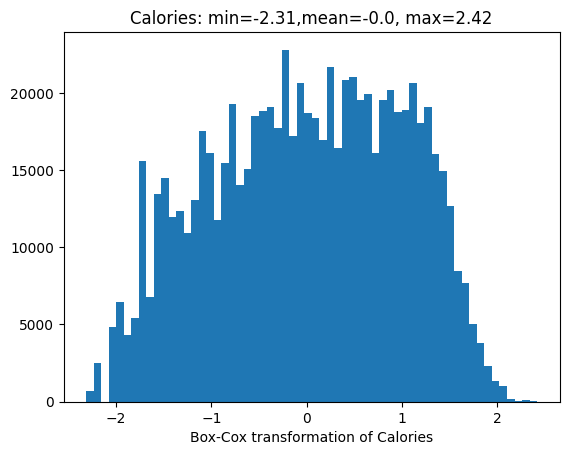

In [14]:
fig, ax = plt.subplots()
ax.hist(Y, bins = 60)
ax.set_title(f'Calories: min={Y.min().round(2)},mean={Y.mean().round(2)}, max={Y.max().round(2)}')
ax.set_xlabel('Box-Cox transformation of Calories')
plt.show()
plt.close()

In [15]:
print('Now Training')

'''
***Main Parameters***
'''
params_A = {'model_seed': 0, 'model_name': 'model_A', 'verbose': 0, 'patience': 14,
           'epochs': CFG.EPOCHS, 'batch_size': CFG.BATCH_SIZE, 
            'lr_cycle': itertools.cycle([1e-4, 1e-6, 4e-6, 1e-6, 6e-7, 6e-7]), 
           'test_seed': 11, 'test_size': 0.20}

model_A = Estimator(**params_A)
print(params_A)
print('Fitting model A')
model_A.generate_model().summary()
model_A.fit(XX1,YY1)

#Validation: {'RMSLE': 0.06472702324390411, 'loss': 0.004189588129520416}
#Validation: {'RMSLE': 0.06281181424856186, 'loss': 0.00394532410427928}
'''
model_A only: 
#FE: Model A
baseline -> Validation: {'RMSE': 0.052987705916166306, 'loss': 0.0028076970484107733}
with F_DxB -> Validation: {'RMSE': 0.05238088220357895, 'loss': 0.002743756864219904}
with F_DxB and F_HxB -> Validation: {'RMSE': 0.05292486026883125, 'loss': 0.002801040653139353}
with F_HxB -> Validation: {'RMSE': 0.05160276219248772, 'loss': 0.002662844955921173}
'''
print()

Now Training
{'model_seed': 0, 'model_name': 'model_A', 'verbose': 0, 'patience': 14, 'epochs': 300, 'batch_size': 32, 'lr_cycle': <itertools.cycle object at 0x7c6c6f7a2c80>, 'test_seed': 11, 'test_size': 0.2}
Fitting model A


Model: "model_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Sex (InputLayer)          │ (32, 1)                │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Age (InputLayer)          │ (32, 1)                │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Height (InputLayer)       │ (32, 1)                │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Weight (InputLayer)       │ (32, 1)                │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Duration (InputLayer)     │ (32, 1)                │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Heart_Rate (InputLayer)   │ (32, 1)                │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Body_Temp (InputLayer)    │ (32, 1)                │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (32, 1, 16)            │             32 │ Sex[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_1 (Embedding)   │ (32, 1, 16)            │            960 │ Age[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_2 (Embedding)   │ (32, 1, 16)            │          1,600 │ Height[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_3 (Embedding)   │ (32, 1, 16)            │          1,552 │ Weight[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_4 (Embedding)   │ (32, 1, 16)            │            480 │ Duration[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_5 (Embedding)   │ (32, 1, 16)            │            992 │ Heart_Rate[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_6 (Embedding)   │ (32, 1, 16)            │            720 │ Body_Temp[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (32, 16)               │              0 │ embedding[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (32, 16)               │              0 │ embedding_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_2 (Flatten)       │ (32, 16)               │              0 │ embedding_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_3 (Flatten)       │ (32, 16)               │              0 │ embedding_3[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_4 (Flatten)       │ (32, 16)               │              0 │ embedding_4[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)  

 Total params: 154,689 (604.25 KB)

 Trainable params: 154,689 (604.25 KB)

 Non-trainable params: 0 (0.00 B)

0epoch [00:00, ?epoch/s]

Validation: {'RMSE': 0.0542018786072731, 'loss': 0.0029378437902778387}



In [16]:
params_B = params_A.copy() #shallow copy
params_B['model_name'] = 'model_B'
params_B['lr_cycle'] = itertools.cycle([1e-4, 1e-6, 4e-6, 1e-6, 6e-7, 6e-7])
params_B['model_seed'] = 1
print(params_B)
model_B = Estimator(**params_B)
print('Fitting model B')

'''Benchmark:
Validation: {'RMSLE': 0.059381432831287384, 'loss': 0.003526154672726989}
'''
model_B.fit(XX2,YY2)

{'model_seed': 1, 'model_name': 'model_B', 'verbose': 0, 'patience': 14, 'epochs': 300, 'batch_size': 32, 'lr_cycle': <itertools.cycle object at 0x7c6bc440b4c0>, 'test_seed': 11, 'test_size': 0.2}
Fitting model B


0epoch [00:00, ?epoch/s]

Validation: {'RMSE': 0.05169631540775299, 'loss': 0.0026725090574473143}


In [17]:
#meta model training:
class MetaEstimator(Estimator):
    def __init__(self,base_models, estimator_config):
        super().__init__(**estimator_config)
        self.base_models = base_models
       
    def generate_model(self):
        keras.utils.clear_session(free_memory = True)
        inx = {}
        base_container = []
        for f in CFG.FEATURES:
            inx[f] = keras.Input(shape = (1,), batch_size = self.batch_size, name = f)

        for base in self.base_models:
            base_model = keras.Model(inputs = base.input, outputs = base.layers[-2].output, name = base.name)
            base_model.trainable = False
            xbase = base_model(inputs = inx)
            base_container.append(xbase)

        out = keras.layers.Concatenate()(base_container)
        out = keras.layers.Dense(128, activation = 'gelu')(out)#original is 128
        bias_initializer_ = keras.initializers.Constant(CFG.BIAS)
        out = keras.layers.Dense(1, activation = 'linear', bias_initializer = bias_initializer_)(out)
        out = keras.ops.clip(out, CFG.MIN_CALORIE, CFG.MAX_CALORIE)
        model = keras.Model(inputs = inx, outputs = out, name = self.model_name)
        return model

    def fit_optimize(self, X, y, learning_rate = [4e-6, 2e-6, 1e-6, 6e-7]):
        '''unlock base model weights and train on very low learning rate'''
        tf.keras.utils.set_random_seed(self.model_seed)
        tf.keras.utils.clear_session(free_memory = True)
        
        if self.is_fitted != True:
            raise Exception('This model is not yet trained!')
            
        self.model = keras.saving.load_model(self.filename)
        for b in self.base_models:
            self.model.get_layer(b.name).trainable = True
        #compile the model:
        self.compile()
        
        # Set a new small learning rate: 
        self.lr_cycle = itertools.cycle(learning_rate)
        
        #callbacks:
        saver_ = keras.callbacks.ModelCheckpoint(filepath = self.filename, mode = 'min', monitor = 'val_loss', 
                                                verbose = self.verbose, save_best_only = True)
        stopper_ = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = self.patience, 
                                                 restore_best_weights = True, mode = 'min')
        monitor_ = TqdmCallback(verbose = 0)
        schedule_ = keras.callbacks.LearningRateScheduler(lambda epoch, lr : next(self.lr_cycle))

        
        #train test split:
        xtrain_, xval_, ytrain_, yval_ = train_test_split(X, y, test_size = self.test_size, 
                                                                         shuffle = True, random_state = self.test_seed)
        
        self.model.fit(x = xtrain_.to_dict(), y= ytrain_, validation_data = [xval_.to_dict(), yval_], verbose = self.verbose, 
                      callbacks = [saver_, stopper_, monitor_, schedule_], batch_size = self.batch_size, 
                       epochs = self.epochs, validation_batch_size = 1024)
        #validation:
        self.evaluation = self.evaluate(X = xval_, y = yval_)
        

print('complete')

complete


In [18]:
mA = keras.saving.load_model(model_A.filename)
mB = keras.saving.load_model(model_B.filename)
base_models = [mA,mB]

main_model_params = {'model_seed': 1, 'model_name': 'main_model', 'verbose': 0, 'patience': 14,
           'epochs':CFG.EPOCHS, 'batch_size': CFG.BATCH_SIZE, 
            'lr_cycle': itertools.cycle([6e-6, 3e-6 , 1e-6 , 6e-7 , 6e-7]), 
           'test_seed': 11, 'test_size': 0.20}

print('main model parameters:')
print(main_model_params)

main_model = MetaEstimator(base_models = base_models, estimator_config = main_model_params)
main_model.generate_model().summary(show_trainable = True)
main_model.fit(XX3, YY3)

main model parameters:
{'model_seed': 1, 'model_name': 'main_model', 'verbose': 0, 'patience': 14, 'epochs': 300, 'batch_size': 32, 'lr_cycle': <itertools.cycle object at 0x7c6be1f584c0>, 'test_seed': 11, 'test_size': 0.2}


Model: "main_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Age (InputLayer)       │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Body_Temp (InputLayer) │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Duration (InputLayer)  │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Heart_Rate             │ (32, 1)              │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Height (InputLayer)    │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Sex (InputLayer)       │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Weight (InputLayer)    │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ model_A (Functional)   │ (32, 128)            │      154,560 │ Age[0][0],          │    N    │
│                        │                      │              │ Body_Temp[0][0],    │         │
│                        │                      │              │ Duration[0][0],     │         │
│                        │                      │              │ Heart_Rate[0][0],   │         │
│                        │                      │              │ Height[0][0],       │         │
│                        │                      │              │ Sex[0][0],          │         │
│                        │                      │              │ Weight[0][0]        │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ model_B (Functional)   │ (32, 128)            │      154,560 │ Age[0][0],          │    N    │
│                        │                      │              │ Body_Temp[0][0],    │         │
│                        │                      │              │ Duration[0][0],     │         │
│                        │                      │              │ Heart_Rate[0][0],   │         │
│                        │                      │              │ Height[0][0],       │         │
│                        │                      │              │ Sex[0][0],          │         │
│                        │                      │              │ Weight[0][0]        │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ concatenate            │ (32, 256)            │            0 │ model_A[0][0],      │    -    │
│ (Concatenate)          │                      │              │ model_B[0][0]       │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ dense (Dense)          │ (32, 128)            │       32,896 │ concatenate[0][0]   │    Y    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ dense_1 (Dense)        │ (32, 1)              │          129 │ dense[0][0]         │    Y    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ clip (Clip)          

 Total params: 342,145 (1.31 MB)

 Trainable params: 33,025 (129.00 KB)

 Non-trainable params: 309,120 (1.18 MB)

0epoch [00:00, ?epoch/s]

Validation: {'RMSE': 0.052312903106212616, 'loss': 0.002736639929935336}


In [19]:
#Evaluation:

'''
{'RMSLE': 0.057704050093889236, 'loss': 0.0033297576010227203} V21
{'RMSLE': 0.05771660432219505, 'loss': 0.0033312065061181784} V22
{'RMSLE': 0.0576416552066803, 'loss': 0.0033225605729967356} V23 LB = 0.05822
V24 : RNG_SEED = 30: LB = 0.05838
V25 : RNG_SEED = 30 -> changed base model lr cycle LB = 0.05838

RMSLE : 0.0636669173836708 -> baesline


'''
validator = RMSLE()
pred = main_model.predict(XX4.to_dict())
pred1 = calorie_transformer.inverse_transform(pred)
actual1 = calorie_transformer.inverse_transform(YY4)
validator.update_state(actual1, pred1)
print(f'Evaluation on Remaining Hidden Data n_rows: {XX4.shape[0]} BEFORE optimization.')
print(f'RMSLE : {validator.result().numpy()}')

validator_2 = keras.metrics.RootMeanSquaredError(name = 'RMSE')
validator_2.update_state(YY4, pred)
print(f'RMSE : {validator_2.result().numpy()}')



Evaluation on Remaining Hidden Data n_rows: 91800 BEFORE optimization.
RMSLE : 0.05816228687763214
RMSE : 0.05166357383131981


In [20]:
def display_residuals(actual, predicted):
    _, ax = plt.subplots(figsize=(12, 5), ncols = 2)
    display = PredictionErrorDisplay.from_predictions(
        y_true = actual, y_pred = predicted, kind="actual_vs_predicted", ax=ax[0], scatter_kwargs={"alpha": 0.5}
    )
    display2 = PredictionErrorDisplay.from_predictions(
        y_true = actual, y_pred = predicted, kind = 'residual_vs_predicted', ax = ax[1], scatter_kwargs={"alpha":0.5})
    plt.show()
    plt.close()
    

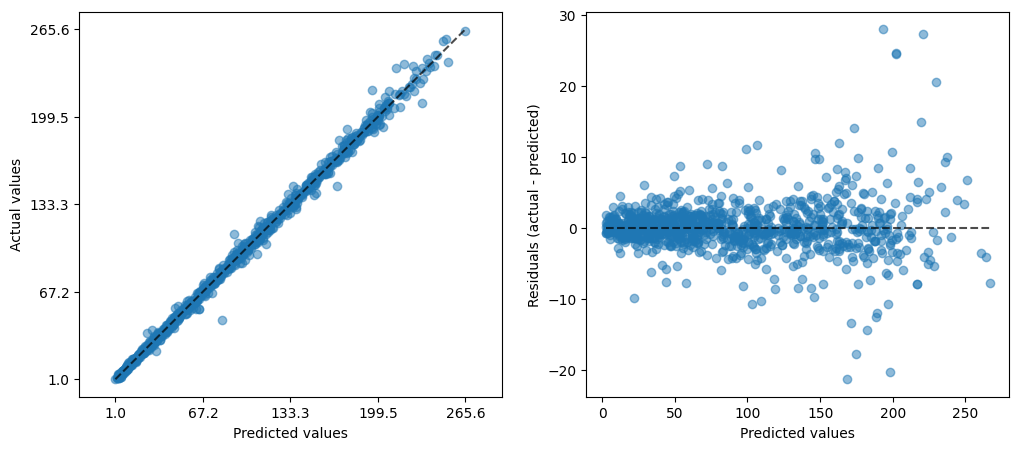

In [21]:
display_residuals(actual = actual1, predicted = pred1)

In [22]:
print('Optimizing at a very low learning rate on Full Training dataset:')
XFull = pl.concat([XX1, XX2, XX3], how = 'vertical')
print(XFull.shape)
YFull = np.r_[YY1, YY2, YY3]
print(YFull.shape)

main_model.verbose = 2
main_model.fit_optimize(X = XFull, y = YFull, learning_rate = [4e-6, 1e-6, 6e-7, 6e-7, 3e-7])

Optimizing at a very low learning rate on Full Training dataset:
(673200, 7)
(673200, 1)


0epoch [00:00, ?epoch/s]

Epoch 1/300

Epoch 1: val_loss improved from inf to 0.00280, saving model to main_model.keras
16830/16830 - 91s - 5ms/step - RMSE: 0.0529 - loss: 0.0028 - val_RMSE: 0.0529 - val_loss: 0.0028 - learning_rate: 4.0000e-06
Epoch 2/300

Epoch 2: val_loss improved from 0.00280 to 0.00276, saving model to main_model.keras
16830/16830 - 84s - 5ms/step - RMSE: 0.0521 - loss: 0.0027 - val_RMSE: 0.0525 - val_loss: 0.0028 - learning_rate: 1.0000e-06
Epoch 3/300

Epoch 3: val_loss improved from 0.00276 to 0.00273, saving model to main_model.keras
16830/16830 - 85s - 5ms/step - RMSE: 0.0519 - loss: 0.0027 - val_RMSE: 0.0522 - val_loss: 0.0027 - learning_rate: 6.0000e-07
Epoch 4/300

Epoch 4: val_loss improved from 0.00273 to 0.00272, saving model to main_model.keras
16830/16830 - 88s - 5ms/step - RMSE: 0.0519 - loss: 0.0027 - val_RMSE: 0.0522 - val_loss: 0.0027 - learning_rate: 6.0000e-07
Epoch 5/300

Epoch 5: val_loss improved from 0.00272 to 0.00271, saving model to main_model.keras
16830/16830 - 

In [23]:
main_model.model.summary(show_trainable = True)

Model: "main_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)           ┃ Output Shape         ┃      Param # ┃ Connected to        ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Age (InputLayer)       │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Body_Temp (InputLayer) │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Duration (InputLayer)  │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Heart_Rate             │ (32, 1)              │            0 │ -                   │    -    │
│ (InputLayer)           │                      │              │                     │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Height (InputLayer)    │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Sex (InputLayer)       │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ Weight (InputLayer)    │ (32, 1)              │            0 │ -                   │    -    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ model_A (Functional)   │ (32, 128)            │      154,560 │ Age[0][0],          │    Y    │
│                        │                      │              │ Body_Temp[0][0],    │         │
│                        │                      │              │ Duration[0][0],     │         │
│                        │                      │              │ Heart_Rate[0][0],   │         │
│                        │                      │              │ Height[0][0],       │         │
│                        │                      │              │ Sex[0][0],          │         │
│                        │                      │              │ Weight[0][0]        │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ model_B (Functional)   │ (32, 128)            │      154,560 │ Age[0][0],          │    Y    │
│                        │                      │              │ Body_Temp[0][0],    │         │
│                        │                      │              │ Duration[0][0],     │         │
│                        │                      │              │ Heart_Rate[0][0],   │         │
│                        │                      │              │ Height[0][0],       │         │
│                        │                      │              │ Sex[0][0],          │         │
│                        │                      │              │ Weight[0][0]        │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ concatenate            │ (32, 256)            │            0 │ model_A[0][0],      │    -    │
│ (Concatenate)          │                      │              │ model_B[0][0]       │         │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ dense (Dense)          │ (32, 128)            │       32,896 │ concatenate[0][0]   │    Y    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ dense_1 (Dense)        │ (32, 1)              │          129 │ dense[0][0]         │    Y    │
├────────────────────────┼──────────────────────┼──────────────┼─────────────────────┼─────────┤
│ clip_1 (Clip)        

 Total params: 342,145 (1.31 MB)

 Trainable params: 342,145 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
validator = RMSLE()
pred = main_model.predict(XX4.to_dict())
pred1 = calorie_transformer.inverse_transform(pred)
actual1 = calorie_transformer.inverse_transform(YY4)
validator.update_state(actual1, pred1)
print(f'Evaluation on Remaining Hidden Data n_rows: {XX4.shape[0]} AFTER optimization.')
print(f'RMSLE : {validator.result().numpy()}')

validator_2 = keras.metrics.RootMeanSquaredError(name = 'RMSE')
validator_2.update_state(YY4, pred)
'''
'''


print(f'RMSE : {validator_2.result().numpy()}')

Evaluation on Remaining Hidden Data n_rows: 91800 AFTER optimization.
RMSLE : 0.057715341448783875
RMSE : 0.051273737102746964


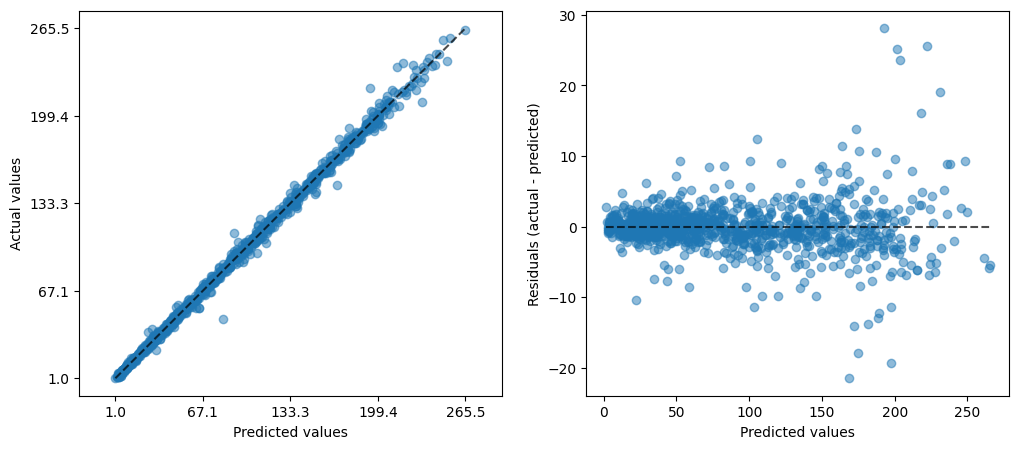

In [25]:
display_residuals(actual = actual1, predicted = pred1)

In [26]:
t = test_df.select(pl.exclude('id')).to_dict()
pred_meta = main_model.predict(t, batch_size = 1024)
pred_meta = calorie_transformer.inverse_transform(pred_meta).ravel()
pred_meta = np.clip(pred_meta, 1, 314)

#predictions = np.c_[pred_A, pred_B, pred_C]
#calories = predictions.mean(axis = -1).ravel()

submission = pl.DataFrame({'id': test_df['id'], 'Calories': pred_meta})
submission.write_csv('submission.csv')
submission.head()


id,Calories
i64,f32
750000,27.113512
750001,108.525902
750002,86.922417
750003,126.323372
750004,76.084023


In [27]:
FileLink('submission.csv')

/kaggle/working/submission.csv